# **Trabajo Práctico: Análisis de Datos de la línea 144**
## Introducción
La linea 144 brinda atención, contención y asesoramiento a personas en situación de violencia de género. Esta línea fue creada en 2013 para cumplir con la ley Nº 26.485 (más información en: https://www.argentina.gob.ar/capital-humano/generos/linea-144).

Se dispone de archivos de datos sobre las llamadas recibidas por este número. Cada registro representa una llamada e incluye información como la fecha, la provincia, el género de la persona que llama, su edad, su nacionalidad, entre otros datos. Los mismos pueden consultarse y descargarse en el sitio https://www.datos.gob.ar/dataset/generos-base-datos-linea-144. En el mismo sitio pueden consultarse los campos con sus tipos de datos y descripción.

En este Proyecto Final se trabajaran con los datos correspondientes a los años 2020 al 2022 (no incluiremos los datos del año 2023 por no estar completos).




## Objetivo del Proyecto final
El objetivo primordial de este Proyecto Final es que el alumno demuestre un empleo adecuado de los elementos y construcciones del lenguaje de programación. Para ello se trabajará con los datos disponibles resolviendo ciertas consignas que se le presentaran en 3 etapas.

A lo largo de tres semanas, trabajarán en la lectura, manipulación y análisis de estos datos, así como en la creación de clases y métodos para comparar y visualizar los resultados.



## Consignas Semana 1:##






1. Descargar los archivos  `datosVG2020.csv`, `datosVG2021.csv` y `datosVG2022.csv` ejectundo el código que se le propone a continuación

In [ ]:
#No modificar este código que le permitirá bajar los archivos que necesita para trabajar
import matplotlib.pyplot as plt
import requests
datosVG2020 = "https://raw.githubusercontent.com/omlisandro26/datos-violencia-genero/main/linea144-2020.csv"
datosVG2021 = "https://raw.githubusercontent.com/omlisandro26/datos-violencia-genero/main/linea144-2021.csv"
datosVG2022 = "https://raw.githubusercontent.com/omlisandro26/datos-violencia-genero/main/linea144-enero-diciembre-2022.csv"

def descargarCSV(url, archivo_salida):
    print("Descargando archivo...")
    consulta = requests.get(url)
    contenido = consulta.content

    print("Guardando archivo...")
    # Abrir conexion en modo escritura
    with open(archivo_salida, "w", encoding="utf-8-sig") as archivo:
        # Escribir el contenido de la consulta
        archivo.write(contenido.decode("utf-8-sig"))

    print("¡Archivo descargado con éxito!")

descargarCSV(datosVG2020, "datosVG2020.csv")
descargarCSV(datosVG2021, "datosVG2021.csv")
descargarCSV(datosVG2022, "datosVG2022.csv")


Descargando archivo...
Guardando archivo...
¡Archivo descargado con éxito!
Descargando archivo...
Guardando archivo...
¡Archivo descargado con éxito!
Descargando archivo...
Guardando archivo...
¡Archivo descargado con éxito!


2. Escribir una función `fusionarArchivosCSV` que tomando una lista de nombres de archivos (con el formato publicado de la linea 144), genere un nuevo archivo con el mismo formato con los datos de los archivos anteriores exceptuando aquellos registros con `fecha` y/o `prov_residencia_persona_en_situacion_violencia` nulos.


3. Invocar a la función `fusionarArchivosCSV` con un lista con los nombres `datosVG2020.csv`, `datosVG2021.csv` y `datosVG2022.csv` y generar un nuevo archivo llamado `datos_filtrados.csv`

In [ ]:
import csv




# 2. Función para fusionar archivos CSV



def fusionarArchivosCSV(lista_archivos_entrada: list, archivo_salida: str) -> None:
    encabezado_escrito = False
    with open(archivo_salida, "w", encoding="utf-8-sig", newline="") as salida:
        writer = csv.writer(salida)
        for nombre_archivo in lista_archivos_entrada:
            with open(nombre_archivo, "r", encoding="utf-8-sig") as entrada:
                reader = csv.reader(entrada)
                encabezado = next(reader)
                if not encabezado_escrito:
                    writer.writerow(encabezado)
                    encabezado_escrito = True
                for fila in reader:
                    writer.writerow(fila)

In [ ]:
# Punto 3: Invocar a la función fusionarArchivosCSV


# Definimos la lista de archivos originales descargados en el punto 1
archivos_origen = ["datosVG2020.csv", "datosVG2021.csv", "datosVG2022.csv"]
archivo_destino = "datos_filtrados.csv"

# Llamamos a la función del Punto 2 para crear el archivo unificado
fusionarArchivosCSV(archivos_origen, archivo_destino)

print(f"¡Éxito! El archivo '{archivo_destino}' ha sido generado.")


¡Éxito! El archivo 'datos_filtrados.csv' ha sido generado.


4. Escribir una función *obtenerAnios* que reciba el nombre de un archivo (con el formato publicado de la linea 144) y devuelva la lista de años que aparecen en el archivo.


In [ ]:
# 4. Obtener años presentes en el archivo.En este bloque, nos aseguramos de que si la fecha usa guiones (formato YYYY-MM-DD), tome el primer elemento ``.

import csv

def obtenerAnios(nombre_archivo: str) -> list[int]:
    anios = set()
    with open(nombre_archivo, "r", encoding="utf-8-sig") as archivo:
        reader = csv.DictReader(archivo)
        for fila in reader:
            # Buscamos 'fecha' o 'Fecha' para que no falle con los datos de 2022
            fecha = fila.get('fecha') or fila.get('Fecha')
            if fecha:
                if "/" in fecha:
                    anio = int(fecha.split("/")[-1])
                else:
                    # El  es lo que evita el error de TypeError: ... not 'list'
                    anio = int(fecha.split("-")[0])
                anios.add(anio)
    return sorted(list(anios))


5. Escribir una función *crearEstadisticasAnualDesdeArchivo* que reciba el nombre de un archivo (con el formato publicado de la linea 144) y un año y devuelva:
- un diccionario donde las claves sean las provincias argentinas desde donde se realizaron llamadas ese año a la linea 144 y los valores son la cantidad de llamadas que recibió cada provincia en dicho año, y
- el promedio de edades de las personas que llamaron a esa línea durante todo el año (como valor entero)




In [ ]:
# 5. Crear estadísticas anuales desde el archivo



import csv

def crearEstadisticasAnualDesdeArchivo(nombre_archivo, anio):

    contar_provincias = {}

    suma_edades = 0
    cantidad_edades = 0

    with open(nombre_archivo, "r", encoding="utf-8-sig") as archivo:

        reader = csv.DictReader(archivo)

        for fila in reader:

            fecha = fila["fecha"]

            if "/" in fecha:
                anio_fila = int(fecha.split("/")[-1])
            else:
                anio_fila = int(fecha.split("-")[0])

            if anio_fila == anio:

                provincia = fila["prov_residencia_persona_en_situacion_violencia"]

                if provincia in contar_provincias:
                    contar_provincias[provincia] += 1
                else:
                    contar_provincias[provincia] = 1

                edad = fila["edad_persona_en_situacion_de_violencia"]

                if edad != "":
                    suma_edades += int(edad)
                    cantidad_edades += 1

    if cantidad_edades > 0:
        promedio_edad = suma_edades // cantidad_edades
    else:
        promedio_edad = 0

    return EstadisticasAnual(
        anio,
        contar_provincias,
        promedio_edad
    )

## Consignas Semana 2:##

**6**. Definir una clase `EstadisticasAnual`

  con los siguientes atributos:
- `anio`: año asociado a la clase,
- `cant_llamadas_por_provincia`: diccionario donde las claves son las provincias argentinas desde donde se realizaron llamadas el año `anio` a la linea 144 y los valores son la cantidad de llamadas que recibió cada provincia en dicho año
- `promedio_edades`: que es el promedio de edades de las personas que llamaron a esa linea durante el año `anio` (como valor entero)

  y los siguientes métodos:
- `__init__`
- `get_anio`
- `get_cant_llamadas_por_provincia`
- `get_promedio_edad_llamantes`
- `__str__`

In [ ]:
"""
La clase EstadisticasAnual se utilizará para mantener información sobre
estadísticas de Situaciones de Violencia en Argentina en un año en particular
"""

class EstadisticasAnual:
    def __init__(self, anio: int, cant_llamadas_por_provincia: dict, promedio_edad_llamantes: int):
        self.anio = anio
        self.cant_llamadas_por_provincia = cant_llamadas_por_provincia
        self.promedio_edad_llamantes = promedio_edad_llamantes

    def getAnio(self) -> int:
        return self.anio

    def getCantLlamadasPorProvincia(self) -> dict:
        return self.cant_llamadas_por_provincia

    def getPromedioEdadLlamantes(self) -> int:
        return self.promedio_edad_llamantes

    def __str__(self) -> str:
        return f"Año: {self.anio} | Promedio Edad: {self.promedio_edad_llamantes} | Provincias registradas: {len(self.cant_llamadas_por_provincia)}"

        # Eeste es el punto 9 que me pide agregareste método dentro de la clase EstadisticasAnual

    def graficarLLamadasPorProvincia(self):

      import matplotlib.pyplot as plt

      provincias = list(self.cant_llamadas_por_provincia.keys())
      cantidades = list(self.cant_llamadas_por_provincia.values())

      plt.figure(figsize=(12, 6))
      plt.bar(provincias, cantidades)

      plt.title("Llamadas por provincia - " + str(self.anio))
      plt.xlabel("Provincia")
      plt.ylabel("Cantidad de llamadas")

      plt.xticks(rotation=90)

      plt.tight_layout()
      plt.show()

7. Escribir una función crearObjetosEstadisticasAnual que tome el nombre de un archivo y devuelva una lista de objetos de la clase EstadisticasAnual, donde cada objeto contiene información de cada año del cual se disponen datos en el archivo. Debe invocar a las funciones `obtenerAnios` y `crearEstadisticasAnualDesdeArchivo`

8. Invocar a la función anterior con el nombre de archivo  `datos_filtrados.csv`.

In [ ]:
# 7. Función para crear la lista de objetos

def crearObjetosEstadisticasAnual(nombre_archivo: str) -> list:

    lista_objetos = []

    anios = obtenerAnios(nombre_archivo)

    for a in anios:

        obj = crearEstadisticasAnualDesdeArchivo(
            nombre_archivo,
            a
        )

        if obj is not None:
            lista_objetos.append(obj)

    return lista_objetos

In [ ]:
# Punto 8: Invocar a la función crearObjetosEstadisticasAnual


lista_estadisticas_anuales = crearObjetosEstadisticasAnual("datos_filtrados.csv")

# Verificamos la carga
print(f"Se han cargado {len(lista_estadisticas_anuales)} años de estadísticas.")


Se han cargado 3 años de estadísticas.


## Consignas Semana 3:##

9. Agregar el método `graficarLLamadasPorProvincia` a la clase `EstadisticasAnual` que muestre en un gráfico de barras la cantidad de llamadas que se hicieron en el año en cuestión desde cada provincia.

10. Realizar las gráficas para los años que se disponen de datos invocando a este método a partir de los objetos creados en el punto 8.

11. Definir una nueva clase `EstadisticasViolencia`

  con el atributo:
- `estadisticasAnuales`: lista de objetos de la clase `EstadisticasAnual`
  
  y los siguientes métodos:
- `__init__`
- `compararPromediosEdadesPorAnio`
- `minimaEdadPromedio`
- `compararGráficamenteDosAnios`
- `__str__`

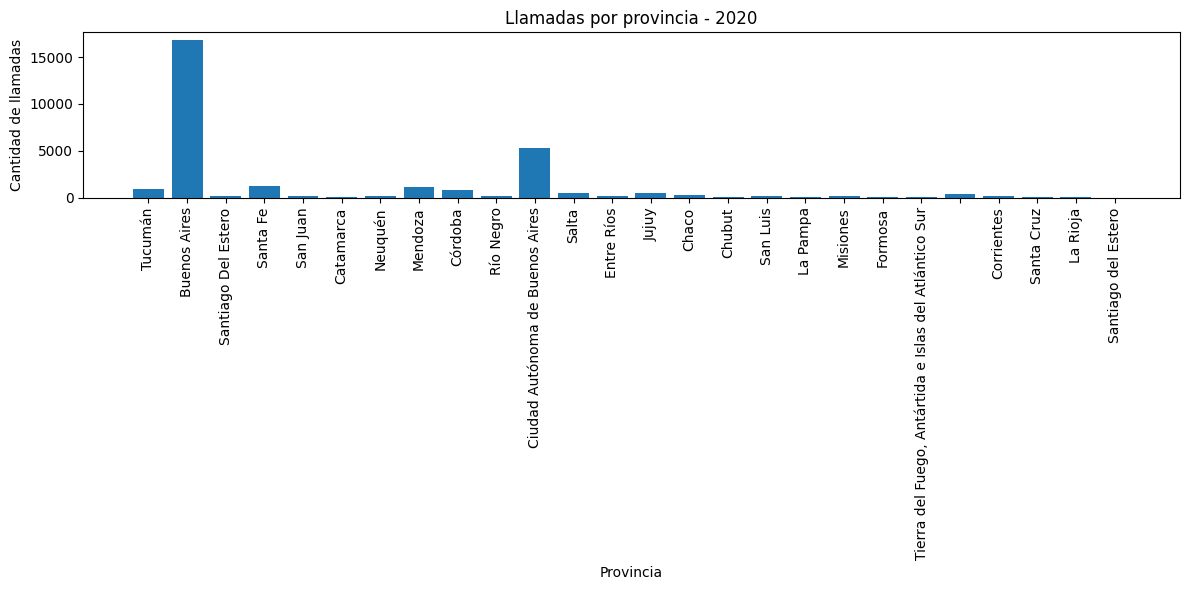

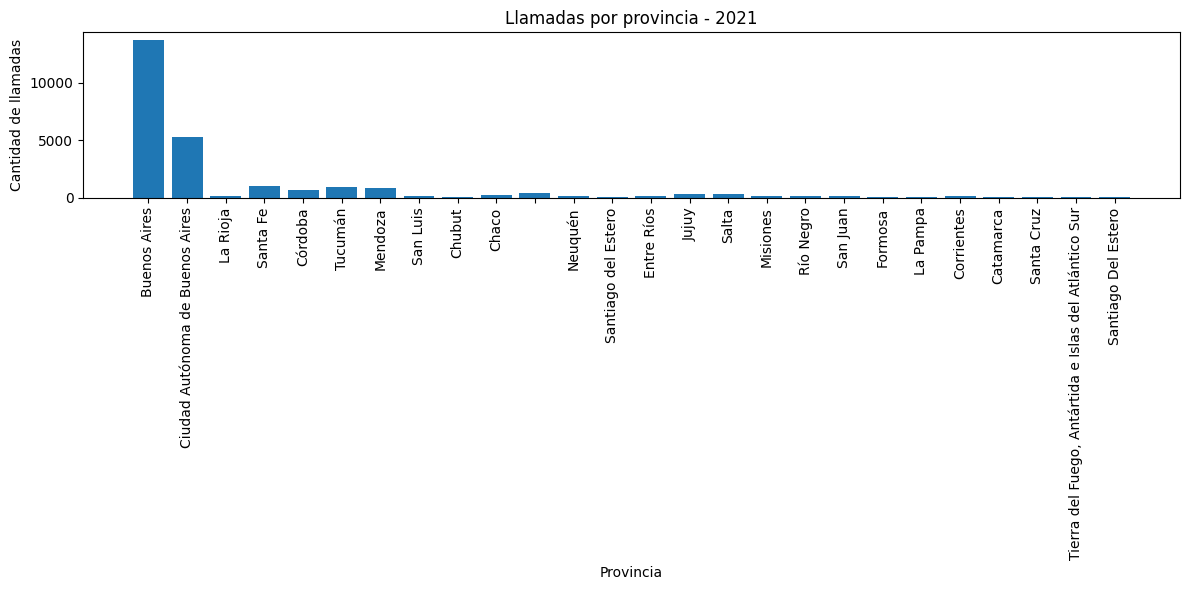

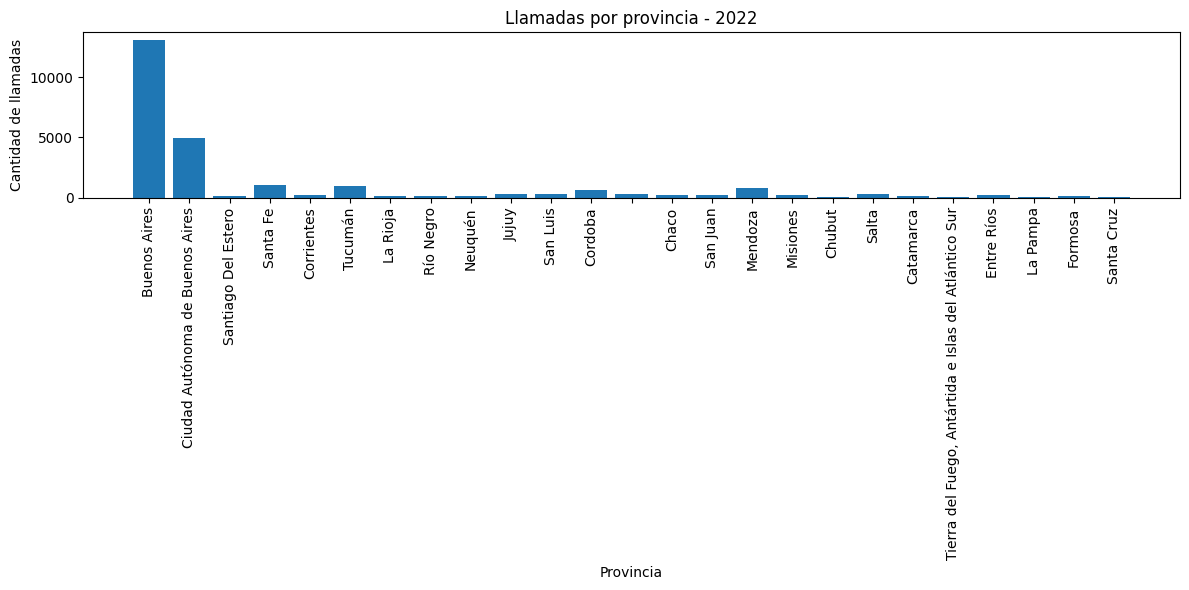

In [ ]:
# Punto 9: hecho en el punto 6 , agregado como metodo a la clase

# Punto 10: Graficar cada año en la lista

for est in lista_estadisticas_anuales:
    est.graficarLLamadasPorProvincia()

In [ ]:
"""
La clase EstadisticasViolencia se utilizará para mantener información sobre
estadísticas de Situaciones de Violencia en Argentina, para todos los años
que se disponga de datos
"""
# Punto 11: creo una nueva clase estadistica violencia con todos sus metodos


class EstadisticasViolencia:
    def __init__(self, estadisticasAnuales: list):
        self.estadisticasAnuales = estadisticasAnuales

    def compararPromediosEdadesPorAnio(self):
        """Imprime el promedio de edad de cada año."""
        print("--- Comparativa de Edad Promedio por Año ---")
        for est in self.estadisticasAnuales:
            print(f"Año {est.getAnio()}: {est.getPromedioEdadLlamantes()} años")

    def minimaEdadPromedioyAnio(self):
      """Busca y muestra el año con el promedio de edad más bajo."""

      if not self.estadisticasAnuales:
        return

      min_est = self.estadisticasAnuales[0]

      for est in self.estadisticasAnuales:

          if est.getPromedioEdadLlamantes() < min_est.getPromedioEdadLlamantes():
            min_est = est

      print(
          f"\nEl año con menor edad promedio fue "
          f"{min_est.getAnio()} "
          f"({min_est.getPromedioEdadLlamantes()} años)"
      )

    def compararGraficamenteDosAnios(self, anio1, anio2):
        """Genera un gráfico comparando el promedio de edad de dos años elegidos."""
        # Buscamos los objetos que coincidan con los años pasados
        est1 = next((x for x in self.estadisticasAnuales if x.getAnio() == anio1), None)
        est2 = next((x for x in self.estadisticasAnuales if x.getAnio() == anio2), None)

        if est1 and est2:
            anios = [str(anio1), str(anio2)]
            promedios = [est1.getPromedioEdadLlamantes(), est2.getPromedioEdadLlamantes()]
            plt.bar(anios, promedios, color=['orange', 'lightgreen'])
            plt.title(f"Comparación Promedio Edad: {anio1} vs {anio2}")
            plt.ylabel("Edad Promedio")
            plt.show()

    def __str__(self):
        return f"Sistema de Análisis de Violencia de Género ({len(self.estadisticasAnuales)} años registrados)"


12. Crear un objeto instanciando la clase `EstadisticasViolencia` que contenga los datos de todos los años disponibles.
13. Invocar a cada uno de los métodos de la clase con el objeto creado en el punto anterior. Compare gráficamente dos años de su elección.

In [ ]:
# Punto 12: creo el objeto global pasandole la lista de objetos que ya tengo

sistema_global = EstadisticasViolencia(lista_estadisticas_anuales)
print(sistema_global)


Sistema de Análisis de Violencia de Género (3 años registrados)


--- Comparativa de Edad Promedio por Año ---
Año 2020: 36 años
Año 2021: 35 años
Año 2022: 35 años

El año con menor edad promedio fue 2021 (35 años)


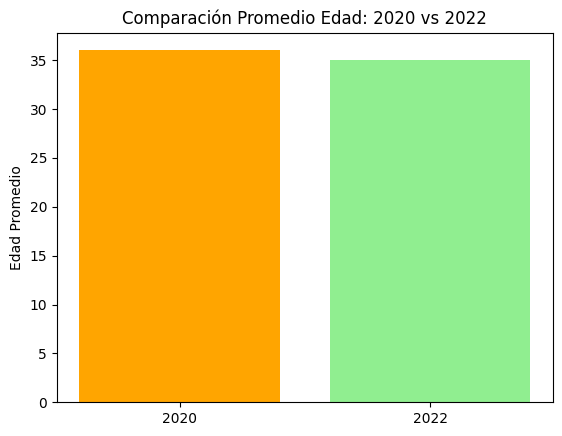

In [ ]:
# Punto 13: Ejecuto y hago el  análisis y comparaciones

sistema_global.compararPromediosEdadesPorAnio()
sistema_global.minimaEdadPromedioyAnio()

# Comparo gráficamente dos años (por ejemplo 2020 y 2022)

sistema_global.compararGraficamenteDosAnios(2020, 2022)